## Import Datas

In [ ]:
import pandas as pd
from scipy.stats import norm
import numpy as np

## Black & Scholes price

In [ ]:
ticker = "MSFT"
option_type="put"

In [ ]:
def black_scholes(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return price

def compute_metrics_for_bs(ticker, option_type):
  data = dataset[ticker]["test"]
  data = data[data["type"] == option_type]
  test_data = data[['time-to-maturity', 'type', 'riskFreeRate', 'sousJacent', 'impliedVolatility', 'strike', "lastPrice"]]

  test_data['BS_price'] = test_data.apply(
    lambda row: black_scholes(
        S=row['sousJacent'],
        K=row['strike'],
        T=row['time-to-maturity'],
        r=row['riskFreeRate'],
        sigma=row['impliedVolatility'],
        option_type=row['type']  # ou 'put'
    ),
    axis=1
)
  return test_data



In [ ]:
rmse = np.sqrt(mean_squared_error(test_data['lastPrice'], test_data['BS_price']))
print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f}")

<Axes: >

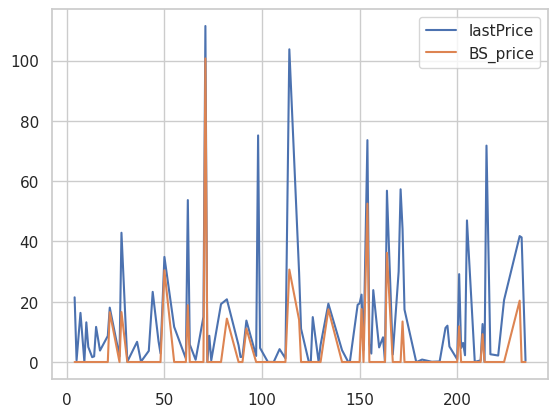

In [ ]:
test_data[["lastPrice", "BS_price"]].head(100).plot()